## Inversion for a coupled acoustic-gravity system

Before running `pip install tinyda ray' 

### Problem setup

Let $\varphi$ be the potential for the flow velocity, it is solution to 
\begin{align}\label{eq:forwardmodel}
    \frac{\partial^2 \varphi}{\partial t^2}
    - c^2 \Delta \varphi 
    + g \frac{\partial \varphi}{\partial z}
    = 0,  \quad \text{ in } \Omega,
    \\
    \frac{\partial^2 \varphi}{\partial t^2}
    + g \frac{\partial \varphi}{\partial z} 
    = 0, \quad \text{ on } \Gamma_s,
    \\
    \nabla \varphi \cdot {\bf n}
    = u_b, \quad \text{ on } \Gamma_b,
\end{align}
where $c$ is the (constant) sound speed, $g$ is the gravity acceleration, ${\bf n}$ is the outwards unit vector normal to the seabed $\Gamma_b$ and $u_b$ is the seabed velocity.
The fluid displacement $u$ is related to the potential by $u = \nabla \varphi$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
from scipy.stats import multivariate_normal
from scipy.spatial.distance import cdist
from scipy.signal import hilbert

import pandas as pd
import tinyDA as tda
import umbridge

/home/dubois/miniconda3/envs/umbridge/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-08-21 10:56:31,161	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


### Initialising UM-Bridge
Before running the following cell, the model Docker image must be started from a system terminal using

`docker run -it -p 4242:4242 acousticgravity`

The Dockerfile can be found in the acousticgracity branch on UM-Bridge benchmarks. If not just running on a local machine replace `localhost` with the server.

In [2]:
# Set all simu parameters 
# Set domain size and simulation time: this info is shared between the forward and parameter models 
Lx = 20
Lz = 1 
TEnd = 10 
H = 1.5

# Informations relative to the parameter model
# Set in the jl server: 
# - number of points to describe the level set passed to the forward model = nx
# - number of points to describe all pressure time series given by the forward model = ny

In [3]:
# Create the config data
#### Change captor location and number
# Each element of the list "captors" is a tuple of (x,z) coordinates. 
# Coordinates are given in the (scaled) domain: x \in [0, grid_size_x], z \in [0, grid_size_y]
sensors = [(4,0.8), (13.5, 0.6)]

# Create sorted sensor list to pass to the forward model: do not change this part 
sensors_sort = np.array(sensors, dtype=[('x',float),('y',float)])
sensors_sort = np.sort(sensors_sort, order=['x','y'])
sensors = sensors_sort.tolist()
n_sensors = len(sensors)
print(n_sensors)

2


In [4]:
# connect to the UM-Bridge model.
umbridge_model = umbridge.HTTPModel('http://localhost:4242', "forward")

# wrap the UM-Bridge model in the tinyDA UM-Bridge interface.
config={"captors":sensors}

# my_model = tda.UmBridgeModel(umbridge_model) # DG: for now without config 
my_model = tda.UmBridgeModel(umbridge_model, umbridge_config=config) # SEM: with config

In [5]:
# For now the DG file does not use the arg config 
nx = umbridge_model.get_input_sizes(config)[0] #the input is the value of f(x) at each grid point
ny = umbridge_model.get_output_sizes(config)[0] #the outout is a time series of the pressure

print(f"input:{nx}, output:{ny}")

input:100, output:202


### Problem setup

In [6]:
# Generate synthetic data
exact = np.zeros(nx)
# True source in the middle of the domain 
idx_middle = int(nx/2)
source_width = 4 # in length unit 
idx_width = int(0.5 * source_width / Lx * nx )
exact[idx_middle - idx_width : idx_middle + idx_width]=1
#print(exact)
d_true = my_model(exact)

# add some noise to the model output
sigma_noise = 0.01
d = d_true + np.random.normal(loc=0, scale=sigma_noise, size=ny)

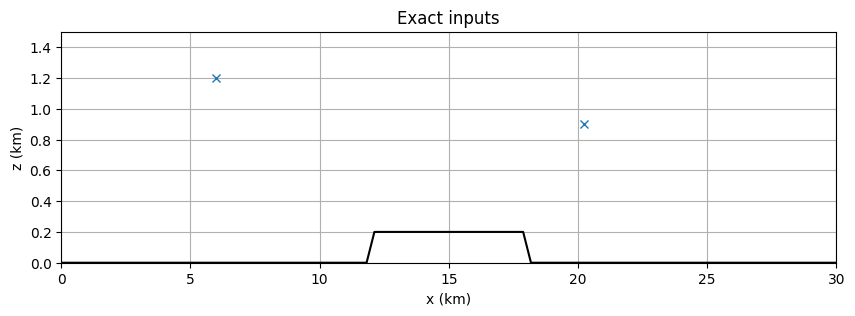

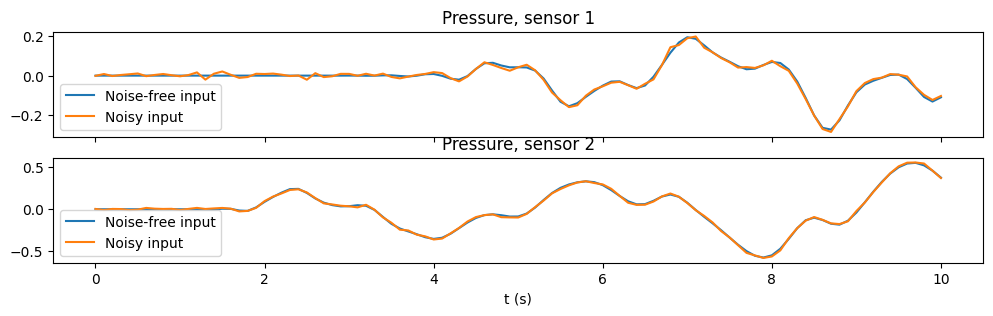

In [7]:
# plot "domain" (to improve)

# Note that the x coords of the sensor are given in scaled coordinates, not in DoFs.
# To plot them, need to find the closest 'dof' corresponding to the scaled coordinates 

# Plot captors location
H = 1.5
x_sensor = np.array(sensors)[:,0]*H
z_sensor = np.array(sensors)[:,1]*H


# Plot exact input location 
# figIn, axIn = plt.subplots(figsize=(24,4))
figIn, axIn = plt.subplots(figsize=(10, 3))
axIn.plot(x_sensor,z_sensor,'x')
axIn.plot(np.linspace(0,Lx,nx)*H, exact*0.2, color="k")
axIn.set_title("Exact inputs")
axIn.set_xlabel("x (km)")
axIn.set_ylabel("z (km)")
axIn.set_xlim(0,Lx*H)
axIn.set_ylim(0,Lz*H)
axIn.grid()


# Plot output from exact location
fig, ax = plt.subplots(2, figsize=(12,3), sharex=True)
t=np.linspace(0, TEnd, ny)
ax[0].set_title('Output from sythetic data')

if(n_sensors==1):
    t = np.linspace(0,TEnd,ny)
    d_true1 = np.array(d_true)
    d_true2 = np.zeros_like(d_true)
    d1 = np.array(d)
    d2 = np.zeros_like(d)
     
if(n_sensors==2):
    t = np.linspace(0,TEnd,int(ny/2))
    d_true1 = np.array(d_true)[0:ny:2]
    d_true2 = np.array(d_true)[1:ny:2]
    d1 = np.array(d)[0:ny:2]
    d2 = np.array(d)[1:ny:2]

ax[0].set_title('Pressure, sensor 1')
ax[0].plot(t,d_true1, label='Noise-free input')
ax[0].plot(t,d1, label='Noisy input')
ax[0].legend()

ax[1].set_title('Pressure, sensor 2')
if(n_sensors==1):
     ax[1].set_title('No sensor 2')
ax[1].plot(t,d_true2, label='Noise-free input')
ax[1].plot(t,d2, label='Noisy input')
ax[1].set_xlabel('t (s)')
ax[1].legend()

#fig.savefig("sensors_fineref")

#print(exact)
#print(d_true)

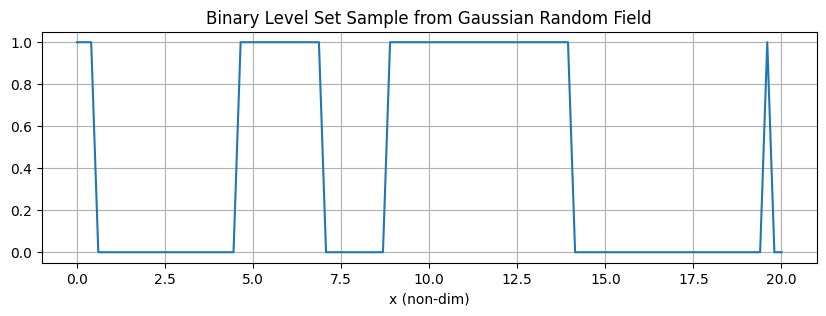

In [8]:
# Create level set of Gaussian random field
# GRF parameters
length_scale = 1
decay_rate = 10

# Level-set parameter
eps = 1e-6

def rbf_covariance(grid, length_scale, variance=1.0):
    dists = cdist(grid, grid, 'euclidean')
    return variance * np.exp(-0.5 * (dists / length_scale) ** 2)

# Use this covariance structure moving forward to match theory
def matern32_covariance(grid, length_scale, variance=1.0):
    dists = cdist(grid, grid, 'euclidean')
    sqrt3 = np.sqrt(3.0)
    scaled_dists = sqrt3 * dists / length_scale
    return variance * (1.0 + scaled_dists) * np.exp(-scaled_dists)

def restriction(sampin):
    field_cut = sampin
    return (field_cut > eps).astype(int)

dx = Lx/nx
x = np.linspace(0, Lx, nx).reshape(-1, 1)
cov = matern32_covariance(x, length_scale)
cov += eps * np.eye(nx)
mean = np.zeros(nx)
my_prior = multivariate_normal(mean=mean, cov=cov)


### Example of a prior 
sample = my_prior.rvs()
sample = restriction(sample)

fig, ax = plt.subplots(figsize=(10, 3))
ax.grid()
ax.plot(x, sample)
ax.set_title("Binary Level Set Sample from Gaussian Random Field")
ax.set_xlabel("x (non-dim)")
plt.show()

[ 6.   20.25] [1.2 0.9]


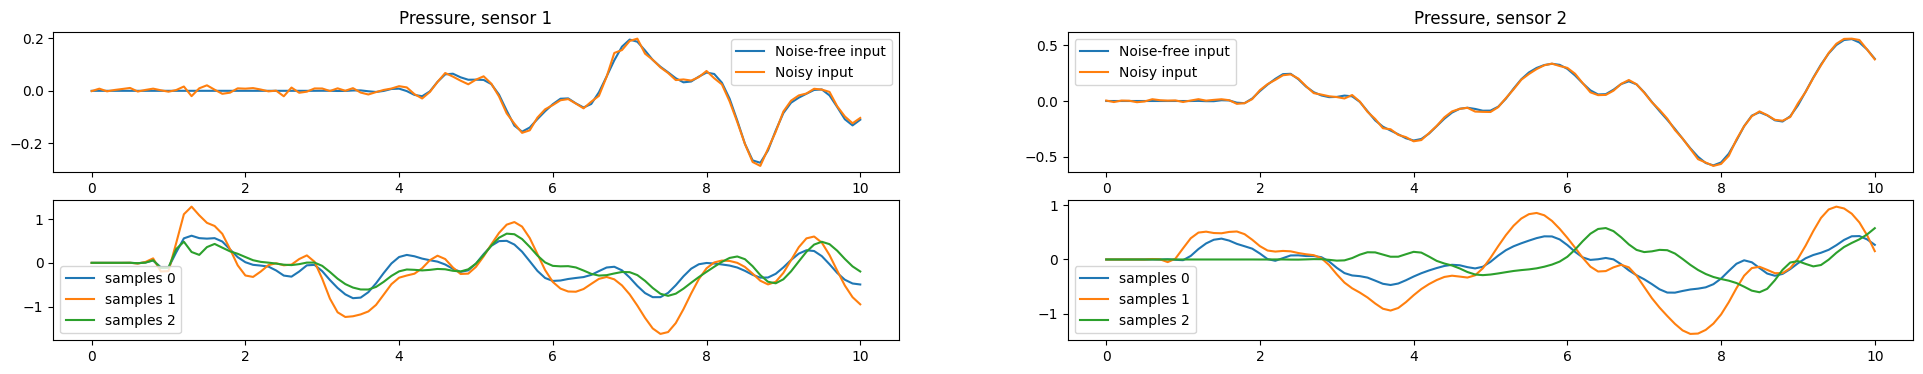

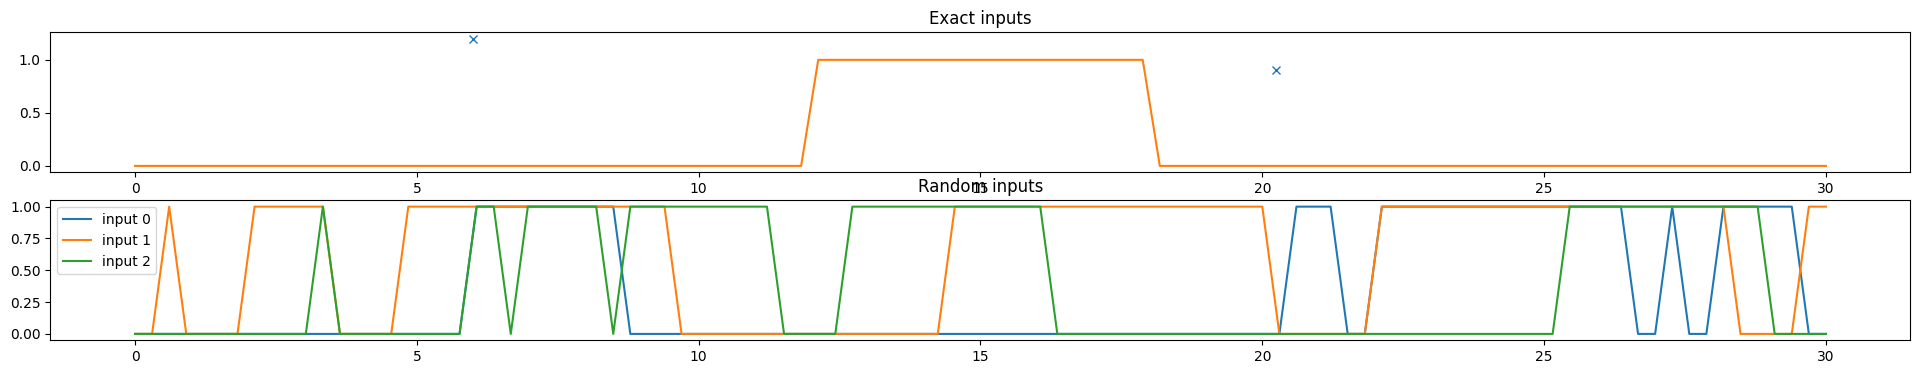

In [9]:
# plot several output and the exact (with/without noise) input/output
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(24,4))
figIn, axIn = plt.subplots(nrows=2, figsize=(24,4))

# exact (with/without noise) input/output 
xCapt = np.array(sensors)[:,0]*H
yCapt = np.array(sensors)[:,1]*H
print(xCapt, yCapt)

axIn[0].plot(xCapt,yCapt,'x')
axIn[0].plot(np.linspace(0,Lx,nx)*H, exact)
axIn[0].set_title("Exact inputs")

if(n_sensors==1):
    t = np.linspace(0,TEnd,ny)
    d_true1 = np.array(d_true)
    d_true2 = np.zeros_like(d_true)
    d1 = np.array(d)
    d2 = np.zeros_like(d)

if(n_sensors==2):
    t = np.linspace(0,TEnd,int(ny/2))
    d_true1 = np.array(d_true)[0:ny:2]
    d_true2 = np.array(d_true)[1:ny:2]
    d1 = np.array(d)[0:ny:2]
    d2 = np.array(d)[1:ny:2]
     
ax[0][0].set_title('Pressure, sensor 1')
ax[0][0].plot(t,d_true1, label='Noise-free input')
ax[0][0].plot(t,d1, label='Noisy input')
ax[0][0].legend()

ax[0][1].set_title('Pressure, sensor 2')
if(n_sensors==1):
     ax[0][1].set_title('No sensor 2')
ax[0][1].plot(t,d_true2, label='Noise-free input')
ax[0][1].plot(t,d2, label='Noisy input')
ax[0][1].legend()


# Plot several random samples
samples = []
inputs=[]
for x in range(3):
    log = my_prior.rvs()
    log = restriction(log)
    #print(log)
    d_sample = my_model(log)
    #print(d_sample)

    if(n_sensors==1):
        d_sample1 = d_sample
        d_sample2 = np.zeros_like(d_sample)
     
    if(n_sensors==2):
        d_sample1 = np.array(d_sample)[0:ny:2]
        d_sample2 = np.array(d_sample)[1:ny:2]
     
    ax[1][0].plot(t, d_sample1, label=f'samples {x}')
    ax[1][1].plot(t, d_sample2, label=f'samples {x}')

    axIn[1].plot(np.linspace(0,Lx,nx)*H, log, label=f'input {x}')
    samples.append(d_sample)
    inputs.append(log)

ax[1][0].legend()
ax[1][1].legend()
axIn[1].set_title("Random inputs")
axIn[1].legend()

plt.show()

## Set up log-likelihood

Test standard Gaussian log-likelihood:
$$\log ⁡L(x)=-0.5(x-y)^T\Sigma^{-1}(x−y)$$

with a Wasserstein-2-based log-likelihood as in Dunlop+Yang, 2021:
$$\log ⁡L(x)\propto -\lambda W_2(x,y),$$

where:
- x = model output
- y = ground truth

with an applied scaling $\sigma(x)$

While $W_1$ is contained in scipy.stats it seems $W_2$ is not

In [95]:
def sigma_linear(v, b):
    return v + b

def sigma_signsensitive(v, b):
    pos = v >= 0
    raw = np.empty_like(v)
    raw[pos] = v[pos] + 1.0 / b
    raw[~pos] = (1.0 / b) * np.exp(b * v[~pos])
    return raw

def sigma_softplus(v, b):
    return np.logaddexp(0.0, b * v)

def sigma_envelope_exp(v, b):
    env = np.abs(hilbert(v))
    return np.exp(b * env)

class WassersteinLoglike:
    """Wasserstein log-likelihood.
    `sigma` is a scaling function"""

    def __init__(self, data, sigma, lam=1.0, b=1.0, n_quantiles=200):
        self.data = np.asarray(data, dtype=float).ravel()
        self.sigma = sigma
        self.lam = lam
        self.b = b
        self.n_quantiles = n_quantiles

    def _density(self, x):
        raw = self.sigma(x, self.b)
        return raw / raw.sum()

    def _quantile_function(self, density):
        cdf = np.cumsum(density); cdf = cdf / cdf[-1]
        t = np.arange(len(density), dtype=float)
        u = (np.arange(self.n_quantiles) + 0.5) / self.n_quantiles
        return np.interp(u, cdf, t)

    def loglike(self, x):
        x = np.asarray(x, dtype=float).ravel()
        p, q = self._density(x), self._density(self.data)
        Fx, Fd = self._quantile_function(p), self._quantile_function(q)
        return -self.lam * np.sum((Fx - Fd) ** 2) / self.n_quantiles

class MultiSensorLoglike:
    """likelihoods: a list of length n_sensors likelihoods, each already
    constructed with its own sensor's reference data."""
    def __init__(self, likelihoods, n_sensors):
        self.likelihoods = likelihoods
        self.n_sensors = n_sensors

    def loglike(self, x):
        x = np.asarray(x, dtype=float).ravel()   # <- use the argument, not a stored copy
        return sum(like.loglike(x[i::self.n_sensors]) for i, like in enumerate(self.likelihoods))
    

    
# Test for Gaussian log like
sigma = 2.0
cov_likelihood = sigma**2*np.eye(d_true.shape[0])
my_loglike_gaussian = tda.GaussianLogLike(d_true, cov_likelihood)

# Test for Wasserstain based log like
# TODO move implementation into tinyDA
my_loglike = MultiSensorLoglike(likelihoods=[
    WassersteinLoglike(d_true[0::n_sensors], sigma_signsensitive, lam=0.001, b=100.0),
    WassersteinLoglike(d_true[1::n_sensors], sigma_signsensitive, lam=0.001, b=400.0),
], n_sensors=2)

my_loglike_linear = MultiSensorLoglike(likelihoods=[
    WassersteinLoglike(d_true[0::n_sensors], sigma_linear, lam=1.0, b=0.1),
    WassersteinLoglike(d_true[1::n_sensors], sigma_linear, lam=1.0, b=1.1),
], n_sensors=2)

my_loglike_envelope = MultiSensorLoglike(likelihoods=[
    WassersteinLoglike(d_true[0::n_sensors], sigma_envelope_exp, lam=35.22, b=5.0),
    WassersteinLoglike(d_true[1::n_sensors], sigma_envelope_exp, lam=72.03, b=5.0),
], n_sensors=2)

In [96]:
print("EY true ", np.exp(my_loglike.loglike(d_true)))
print("EY true + small noise ", np.exp(my_loglike.loglike(d)))
print("linear true ", np.exp(my_loglike_linear.loglike(d_true)))
print("linear true + small noise ", np.exp(my_loglike_linear.loglike(d)))
print("power true ", np.exp(my_loglike_power.loglike(d_true)))
print("power true + small noise ", np.exp(my_loglike_power.loglike(d)))

#print(d_true)
#print(d)

EY true  1.0
EY true + small noise  0.9791390929061162
linear true  1.0
linear true + small noise  0.668378244704583
power true  1.0
power true + small noise  0.997386322968668


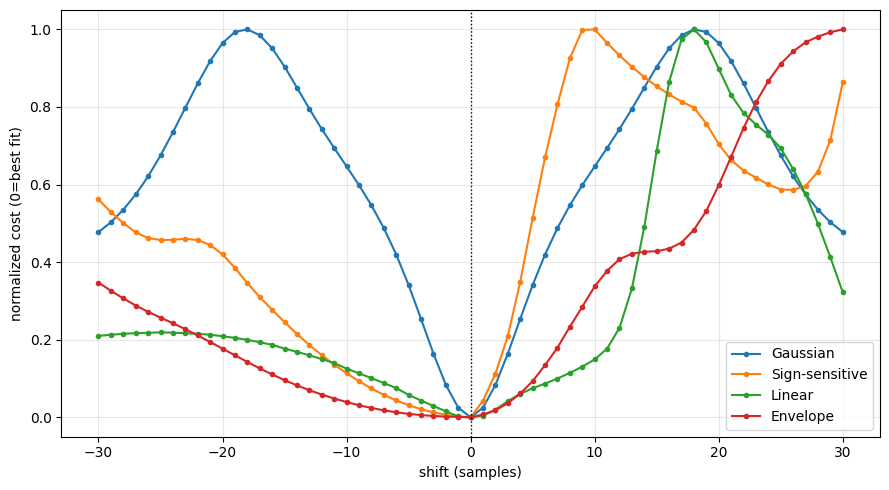

In [97]:
def shift_per_sensor(flat_signal, shift, n_sensors):
    flat_signal = np.asarray(flat_signal, dtype=float).ravel()
    parts = [np.roll(flat_signal[i::n_sensors], shift) for i in range(n_sensors)]
    out = np.empty_like(flat_signal)
    for i, p in enumerate(parts):
        out[i::n_sensors] = p
    return out

likelihoods = {
    "Gaussian": my_loglike_gaussian,
    "Sign-sensitive": my_loglike,
    "Linear": my_loglike_linear,
    "Envelope": my_loglike_envelope,
}

shifts = np.arange(-30, 31)
fig, ax = plt.subplots(figsize=(9, 5))
for name, like in likelihoods.items():
    vals = np.array([-like.loglike(shift_per_sensor(d_true, s, n_sensors)) for s in shifts])
    ax.plot(shifts, vals / (vals.max() or 1), label=name, marker='.')
ax.axvline(0, color='k', ls=':', lw=1)
ax.set_xlabel("shift (samples)")
ax.set_ylabel("normalized cost (0=best fit)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

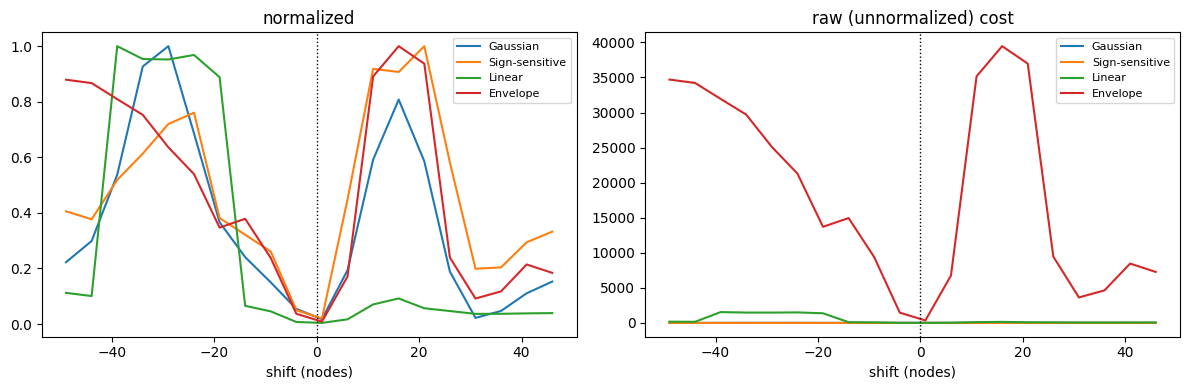

In [98]:
def shift_levelset(levelset, shift):
    out = np.zeros_like(levelset)
    if shift > 0:
        out[shift:] = levelset[:-shift]
    elif shift < 0:
        out[:shift] = levelset[-shift:]
    else:
        out[:] = levelset
    return out

shifts = np.arange(-49, 50, 5)
candidate_outputs = {}
for s in shifts:
    shifted_input = shift_levelset(exact, s)
    candidate_outputs[s] = my_model(shifted_input)

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for name, m in likelihoods.items():
    vals = np.array([-m.loglike(out) for out in candidate_outputs.values()])
    ax[0].plot(shifts, vals / (vals.max() or 1), label=name)
    ax[1].plot(shifts, vals, label=name)

ax[0].axvline(0, color='k', ls=':', lw=1)
ax[0].set_xlabel("shift (nodes)")
ax[0].set_title("normalized")
ax[0].legend(fontsize=8)

ax[1].axvline(0, color='k', ls=':', lw=1)
ax[1].set_xlabel("shift (nodes)")
ax[1].set_title("raw (unnormalized) cost")
ax[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [100]:
# initialise the Posterior
def levelset_model(parameters):
    levelset_params = restriction(parameters)
    return my_model(levelset_params)

my_posterior = tda.Posterior(my_prior, my_loglike_power, levelset_model)
#my_posterior = tda.Posterior(my_prior, my_loglike, my_model)

### Set up the proposal

In [101]:
# Custom Crank-Nicolson with cutoff and levelset
class CrankNicolson(tda.CrankNicolson):
    def __init__(self, scaling, adaptive):
        super().__init__(scaling=scaling, adaptive=adaptive)

    def make_proposal(self, link):
        # make a pCN proposal.
        self.scaling = min(self.scaling, 1.0 - 1e-3)
        return np.sqrt(
            1 - self.scaling**2
        ) * link.parameters + self.scaling * np.random.multivariate_normal(
            self._mean, self.C
        )

# preconditioned Crank-Nicolson
pcn_scaling = 0.15
pcn_adaptive = True
my_proposal = CrankNicolson(scaling=pcn_scaling, adaptive=pcn_adaptive)

# # random walk Metropolis
#rwmh_cov = np.eye(nx)
#rmwh_scaling = 0.1
#rwmh_adaptive = False
#my_proposal = tda.GaussianRandomWalk(C=rwmh_cov, scaling=rmwh_scaling, adaptive=rwmh_adaptive)

### Sample

In [ ]:
# For testing purposes, iteration number is small for the given problem; Choose a larger number for real applications.
my_chains = tda.sample(my_posterior, my_proposal, iterations=10000, n_chains=2, force_sequential=True)

Sampling chain 1/2


Running chain, α = 0.54:  99%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████ | 9944/10000 [13:19:05<04:28,  4.80s/it]

### Get some diagnostics

Execute next two cells to store!

In [201]:
import arviz as az

In [202]:
# convert the tinyDA chains to an ArViz InferenceData object.
burnin = 0
idata = tda.to_inference_data(my_chains, burnin=burnin)
az.to_netcdf(idata, "results_dg_10000.nc") # to store
#idata = az.from_netcdf("results_wassersteinlog.nc")# to load

/home/anne/.local/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: qoi group is not defined in the InferenceData scheme
  warnings.warn(


In [203]:
print(idata)
print(idata.sample_stats)

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> qoi
<xarray.Dataset> Size: 56kB
Dimensions:     (chain: 2, draw: 1001)
Coordinates:
  * chain       (chain) int64 16B 0 1
  * draw        (draw) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999 1000
Data variables:
    prior       (chain, draw) float64 16kB -0.5348 0.522 0.522 ... 8.069 8.069
    likelihood  (chain, draw) float64 16kB -3.761e+04 -2.786e+04 ... -5.618e+03
    posterior   (chain, draw) float64 16kB -3.761e+04 -2.786e+04 ... -5.61e+03


In [204]:
# display posterior summary statistics.
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", None)
info = az.summary(idata);
info

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
x0,-0.386,0.566,-1.350,0.689,0.335,0.266,3.0,12.0,1.68
x1,-0.452,0.414,-1.297,0.145,0.221,0.172,3.0,18.0,1.72
x2,-0.419,0.490,-1.409,0.394,0.305,0.246,3.0,19.0,2.10
x3,-0.381,0.585,-1.747,0.365,0.382,0.313,3.0,21.0,2.34
x4,-0.305,0.634,-1.812,0.486,0.407,0.331,3.0,22.0,2.17
x5,-0.205,0.672,-1.578,0.763,0.427,0.347,3.0,22.0,2.07
x6,-0.078,0.590,-1.405,0.745,0.373,0.303,3.0,11.0,2.12
x7,-0.190,0.435,-1.005,0.669,0.247,0.194,3.0,22.0,1.78
x8,-0.394,0.428,-1.302,0.273,0.240,0.191,3.0,15.0,1.65
x9,-0.463,0.485,-1.451,0.095,0.263,0.230,3.0,12.0,1.59


/home/anne/.local/lib/python3.12/site-packages/arviz/plots/traceplot.py:223: UserWarning: rcParams['plot.max_subplots'] (20) is smaller than the number of variables to plot (100), generating only 20 plots
  warnings.warn(


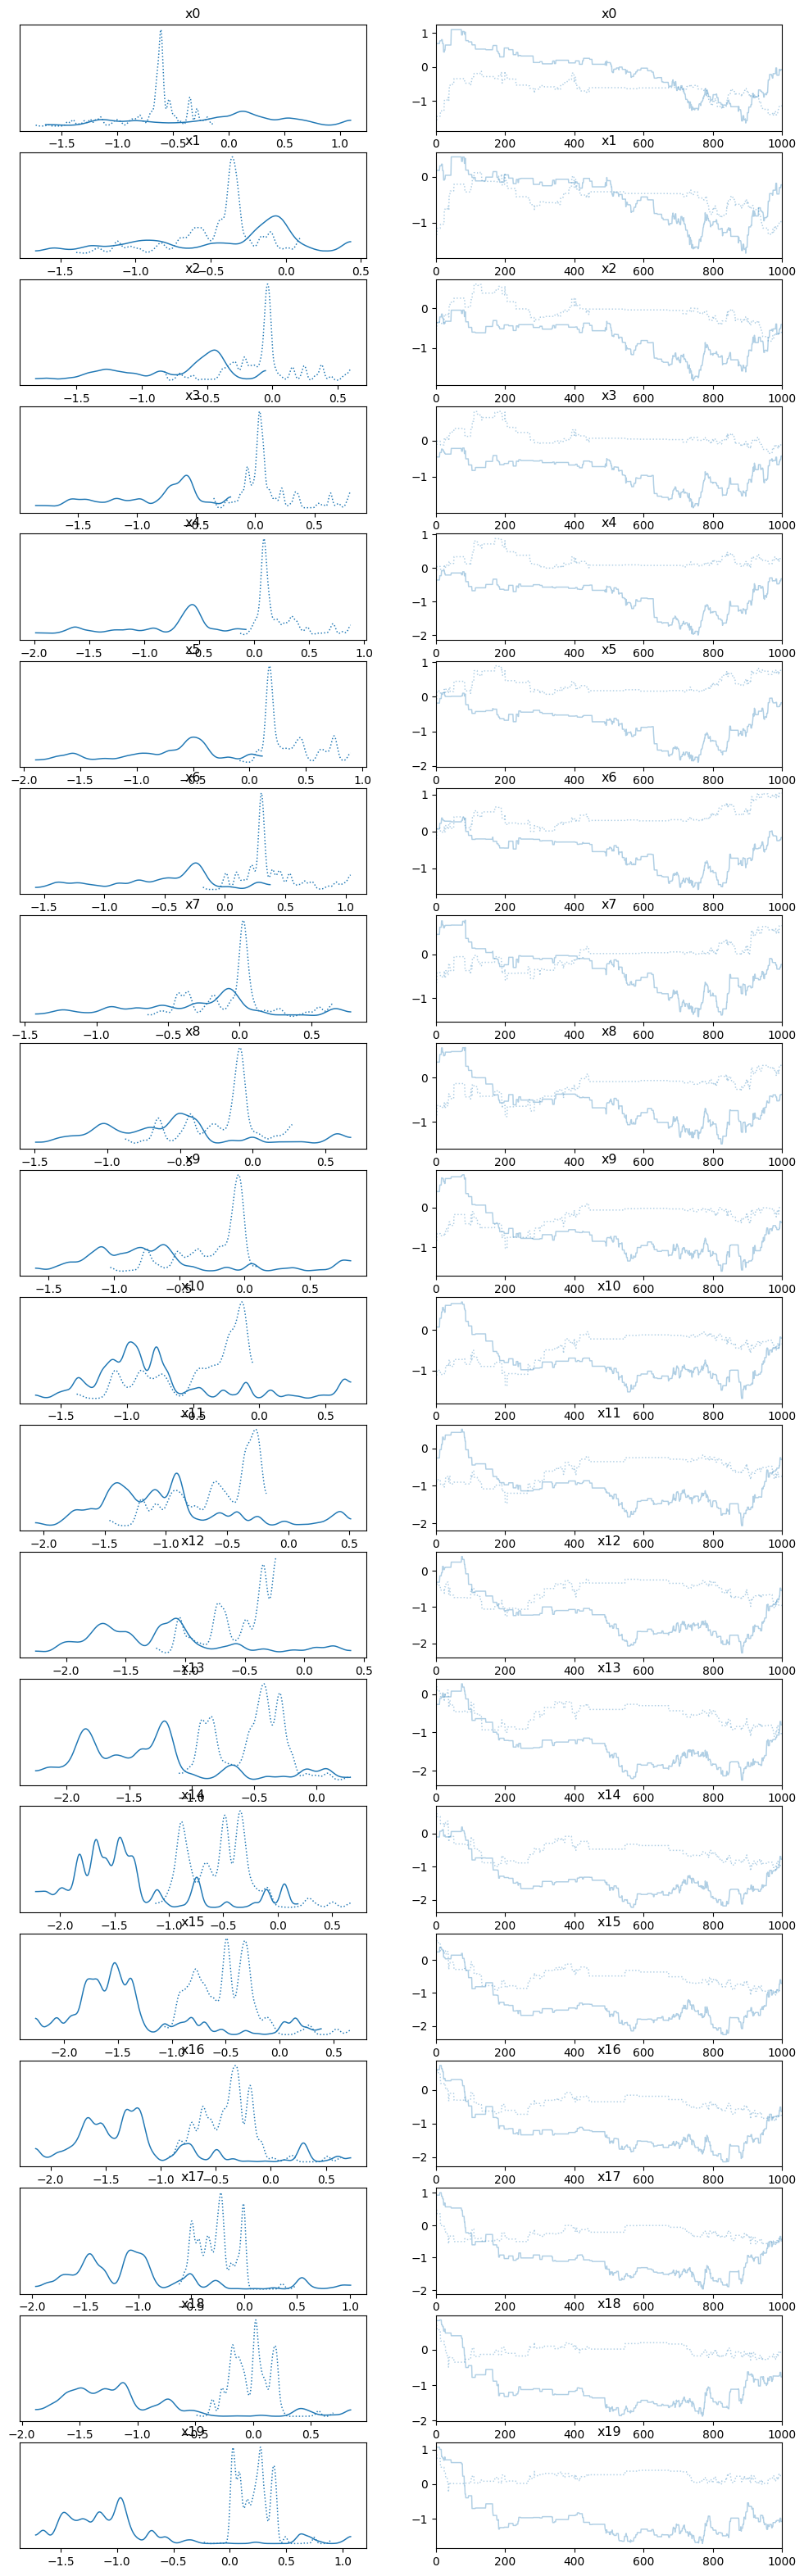

In [205]:
# plot posterior kernel densities and traces.
az.plot_trace(idata)
plt.show()

In [206]:
# extract the parameters from the chains.
subsampling_rate = 1
burnin = 500
#parameters = [link.parameters for link in my_chains['chain_0'][burnin::subsampling_rate] + my_chains['chain_1'][burnin::subsampling_rate]]

# If loaded data need to do this, otherwise above is easier
idata_sub = idata.sel(draw=slice(burnin, None, subsampling_rate))
parameters = []
for i in range(idata_sub.posterior.draw.size):
    parameters = [
        np.array([idata_sub.posterior[var].values[0, i] for var in idata_sub.posterior.data_vars])
        for i in range(idata_sub.posterior.draw.size)
    ]

In [207]:
n_samples = 10
ids = np.random.randint(0, len(parameters), n_samples)

# Evaluate model outputs and likelihoods
likelihoods = []
outputs = []

for i in ids:
    param = parameters[i]
    output = levelset_model(param)
    outputs.append(output)
    idata_sub = idata.sel(draw=slice(None, None, subsampling_rate))
    loglikes = idata_sub.sample_stats["likelihood"].values.flatten()
    #print("Likelihood ", loglikes[i])
    likelihoods.append(loglikes[i])

# Normalize likelihoods for colormap
likelihoods = np.array(likelihoods)
norm = colors.Normalize(vmin=np.min(likelihoods), vmax=np.max(likelihoods))
cmap = cm.viridis  # Or any matplotlib colormap
colors_list = [cmap(norm(l)) for l in likelihoods]

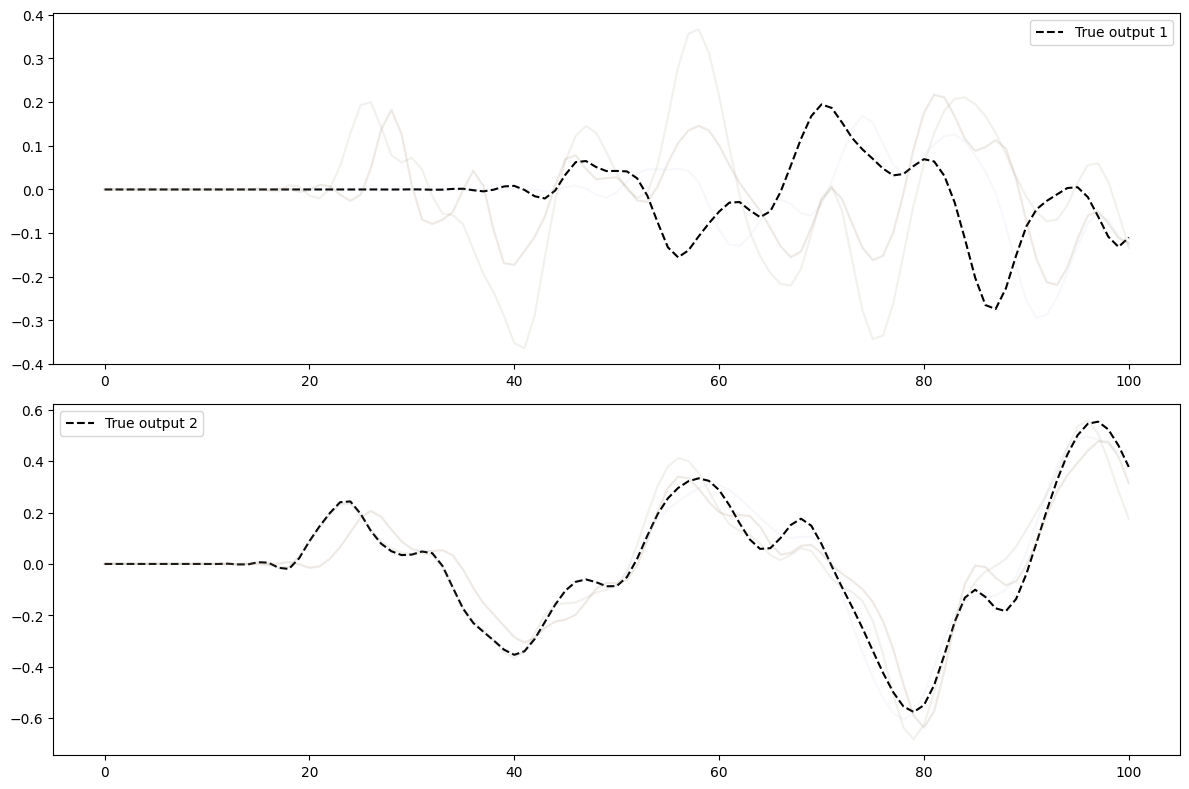

In [208]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 8))

d_true = np.array(d_true)
ax[0].plot(d_true[::2], 'k--', label="True output 1")
ax[1].plot(d_true[1::2], 'k--', label="True output 2")
for output in outputs:
    ax[0].plot(output[::2], alpha=0.03)
    ax[1].plot(output[1::2], alpha=0.03)
ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()

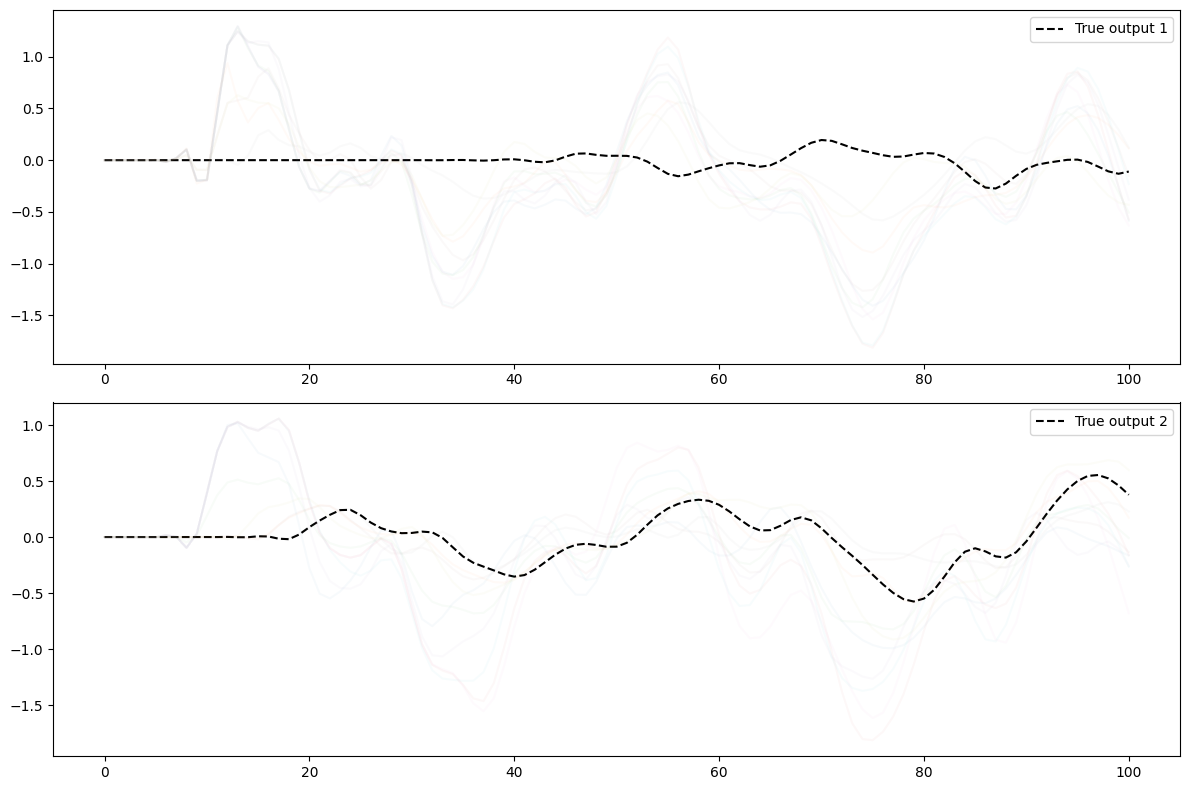

In [209]:
n_samples = 10

# Evaluate model outputs and likelihoods
likelihoods = []
outputs = []

# Compare with draws from the prior
for ids in range(n_samples):
    log = my_prior.rvs()
    log = restriction(log)
    output = levelset_model(log)
    outputs.append(output)
    idata_sub = idata.sel(draw=slice(None, None, subsampling_rate))
    loglikes = idata_sub.sample_stats["likelihood"].values.flatten()
    likelihoods.append(loglikes[i])

# Normalize likelihoods for colormap
likelihoods = np.array(likelihoods)
norm = colors.Normalize(vmin=np.min(likelihoods), vmax=np.max(likelihoods))
cmap = cm.viridis  # Or any matplotlib colormap
colors_list = [cmap(norm(l)) for l in likelihoods]

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 8))

d_true = np.array(d_true)
ax[0].plot(d_true[::2], 'k--', label="True output 1")
ax[1].plot(d_true[1::2], 'k--', label="True output 2")
for output in outputs:
    ax[0].plot(output[::2], alpha=0.03)
    ax[1].plot(output[1::2], alpha=0.03)
ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()

IndexError: list index out of range

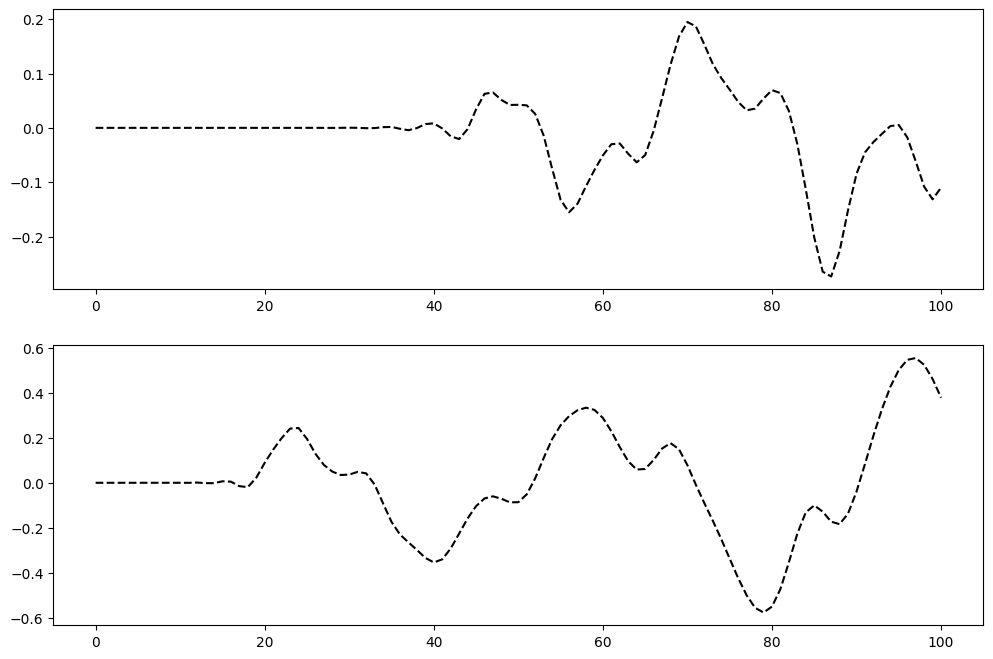

In [210]:
# Extract corresponding likelihoods
likelihoods = idata_sub.sample_stats["likelihood"].values[0, :]

# Sort parameter sets by decreasing likelihood
sorted_indices = np.argsort(-likelihoods)  # Negative for descending order
top_indices = sorted_indices[:5]

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 8))

d_true = np.array(d_true)
ax[0].plot(d_true[::2], 'k--', label="True output 1")
ax[1].plot(d_true[1::2], 'k--', label="True output 2")

for i in top_indices:
    param = parameters[i]
    output = np.array(levelset_model(param))
    loglike = likelihoods[i]
    ax[0].plot(output[::2], alpha=0.3, label=f"loglike: {loglike:.2f}")
    ax[1].plot(output[1::2], alpha=0.3, label=f"loglike: {loglike:.2f}")

ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
x=np.linspace(0,nx, nx)
t=np.linspace(0,25, int(ny/2))
d1 = np.array(d_true)[0:ny:2]
d2 = np.array(d_true)[1:ny:2]

output = levelset_model(info['mean'])
o1 = np.array(output)[0:ny:2]
o2 = np.array(output)[1:ny:2]

fig, ax = plt.subplots(figsize=(12,2))
ax.plot(t,d1, label='True output 1')
ax.plot(t,o1, label='mean output 1')
ax.legend()

fig, ax = plt.subplots(figsize=(12,2))
ax.plot(t,d2, label='True output 2')
ax.plot(t,o2, '--' ,label='mean output 2')
ax.legend()

In [ ]:
x = range(len(info))
plt.figure(figsize=(8, 6))
plt.plot(exact)
plt.title('Exact input')
eps = 5e-2
plt.plot(x, restriction(info['mean']), 'o')  # x = index, y = mean
#plt.plot(x, info['mean'], 'x')  # x = index, y = mean
#print(top_links[0])
#plt.plot(x, restriction(parameters[top_indices[0]]), 'x')  # x = index, y = mean
plt.plot([sensors[0][0]*nx/Lx,sensors[1][0]*nx/Lx],[0,0],'x')
plt.ylabel('mean')
plt.title('Posterior Means')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
az.plot_autocorr(idata);

In [ ]:
az.plot_posterior(idata);

In [ ]:
az.plot_rank(idata);

## Sequential Monte Carlo

Adjustments:
- replace manual logging with arvis inference structure (easier/faster saving in netcdf format, immediate access to plotting routines)
- replace prior class with scipy priors (compatibility with tinyDA code above)
- replace loglikelihood class with tinyDA style loglikelihood
- replace MCMC steps with tinyDA

In [16]:
from os import sys, path, getcwd
sys.path.append(path.dirname(getcwd()))

import functools as ft

import warnings
import matplotlib.cbook
import scipy.stats as stats

from SMC import *

Finished: Wed Jul 30 16:08:34 2025


Start with the example provided before moving on to more complex model

In [51]:
### M:  number of particles/samples for SMC
num_samples = 10

### var: uncertainty variance of measurements/modeling
std_noise = 0.05

### Title for saving the results
run = "acousticgravity"  # or any identifier you want
resultspath = f'RESULTS/SMC_M_{num_samples}_{run}'

In [52]:
# Wrapper for scipy prior
class prior:
    def __init__(self, prior, d = 1):
        self.d = d # dimension of prior/parameter space, here 1
        self.RV = prior # this is specific to this prior

    def rvs(self, M):
        # Generate n samples. The resulting numpy array must be [1:d, 1:M]
        return np.array([self.RV.rvs(size=M) for i in range(self.d)])

    def logpdf(self, particle):
        # Compute logpdf at a point "particle"-
        return np.sum([self.RV.logpdf(particle[i]) for i in range(self.d)])

nx = 1 # 1D test case just to start!
length_scale = 5.0
eps = 1e-6
decay_rate = 10

x = np.linspace(0, nx - 1, nx).reshape(-1, 1)
def rbf_covariance(grid, length_scale, variance=1.0):
    dists = cdist(grid, grid, 'euclidean')
    return variance * np.exp(-0.5 * (dists / length_scale) ** 2)

cov = rbf_covariance(x, length_scale)
cov += eps * np.eye(nx)
mean = np.zeros(nx)
my_prior = prior(stats.multivariate_normal(mean=mean, cov=cov), d=1)

In [53]:
### Set up forward model
def forward_model(x0):
    #Transform x0 to single location in input parameter vector (simplified testcase, to be replaced later)
    # True x0 is 70
    nx = umbridge_model.get_input_sizes(config)[0]
    xvec = np.zeros(nx)
    if 0 <= x0[0] - 10 < nx: xvec[int(x0[0]) - 10] = 1
    if 0 <= x0[0] + 10 < nx: xvec[int(x0[0]) + 10] = 1
    output = levelset_model(xvec)   
    return output

def potential(particle, data, std_noise = 0.05):
    fwd_vals = forward_model(particle)
    #return 1.*(np.linalg.norm(fwd_vals-data)**2/(2.*std_noise**2)) 
    return my_loglike.loglike(fwd_vals)

# Multiprocessing evaluation of previous potential 
def potential_mp(particles,data, std_noise = 0.05):
    pool = mp.Pool()
    potentials = pool.map(ft.partial(potential, data=data, std_noise=std_noise),particles.T)
    pool.close()
    return np.array(potentials)


In [54]:
### SET UP SMC SAMPLER  
SMC_sampler = SMC(my_prior, lambda x: potential_mp(x, data = d_true, std_noise = std_noise), resultspath, d_true, num_samples)
SMC_sampler.smc_tempering() ### perform SMC algorithm

SMC for RESULTS/SMC_M_10_acousticgravity - Started: Wed Jul 30 16:20:34 2025
------ TEMPERING-STEP 0 --------------------------

>> REWEIGHTED with exponent 1.0
>> NOT resampled (ESS 99.99% , exponent = 1)

--- duplicates: 0/10  |  highest count: 1x
Applying MCMC kernel 4 times 

Acceptance ratio: 0.8 >0.3 
  => variance scaling: 1.0->2.0
>> MCMC complete!
--- duplicates: 0/10  |  highest count: 1x
[saved intermediate result]
Tempering finished!
Tempering steps done:  0
